In [1]:
#Save monthly data - June 2024
import pandas as pd
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import glob
import seaborn as sns  # Optional for aesthetics
import datetime
import numpy as np
import cmocean

data_path  = '/Users/epauthen/Documents/Database/Antarctic_Sea_Ice/v3p0/'
out_path   = '/Users/epauthen/Documents/Database/Antarctic_Sea_Ice/v3p0_monthly_mean/'


In [3]:
for yy in np.arange(1987, 2025):
    ds = xr.open_mfdataset(f'{data_path}/{yy}/*/*.nc')
    dsm = ds[['ice_conc']].groupby('time.month').mean(dim='time')
    months = np.arange(1, 13)  # Months from January to December
    time_coord = pd.to_datetime({'year': yy, 'month': months, 'day': np.ones_like(months)})
    dsm = dsm.assign_coords(month=("month", time_coord))
    dsm = dsm.rename({'month': 'time'})
    
    dsm.to_netcdf(f'{out_path}/{yy}_monthly_mean.nc')
    print(f'{yy} done')


2024 done


/Users/epauthen/opt/anaconda3/lib/python3.8/site-packages/dask/array/numpy_compat.py:39: RuntimeWarning: invalid value encountered in true_divide
  x = np.divide(x1, x2, out)


In [ ]:
#Check the output
ds = xr.open_dataset(f'{out_path}/2023_monthly_mean.nc')
ds

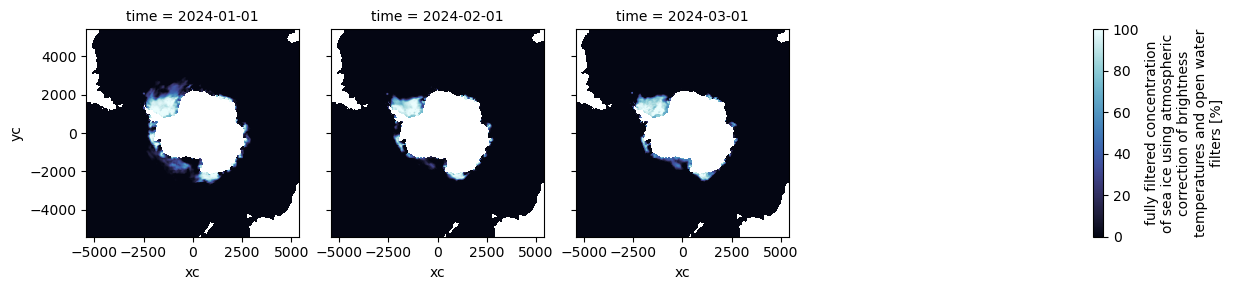

In [4]:
#save plot by year
for yy in np.arange(2024, 2025):
    ds = xr.open_dataset(f'{out_path}/{yy}_monthly_mean.nc')
    ds['ice_conc'].plot(x='xc', y='yc', cmap=cmocean.cm.ice, col='time', col_wrap=4)
    plt.savefig(f'{out_path}/{yy}_monthly_mean.png')

In [ ]:
ls -l /Users/epauthen/Documents/Database/Antarctic_Sea_Ice/v3p0_monthly_mean/